In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("C:\\Users\\ppagi\\Downloads\\netflix_titles.csv\\netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [8]:
df['director'].fillna('Unknown', inplace=True)

In [9]:
df['cast'].fillna('Unknown', inplace=True)

In [10]:
df['country'].fillna('Unknown', inplace=True)

In [11]:
df['date_added'] = df['date_added'].str.strip()

In [12]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

In [13]:
df['rating'].fillna('Unknown', inplace=True)

In [14]:
df['duration'].fillna('Unknown', inplace=True)

In [15]:
df = df.dropna(subset=['date_added'])

In [16]:
df.duplicated().sum()

0

## Feature Engineering


In [17]:
df['year_added']=df['date_added'].dt.year

In [18]:
df['month_added']=df['date_added'].dt.month

In [19]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

In [20]:
df[['country', 'type']].value_counts().head(10)

country         type   
United States   Movie      2058
India           Movie       893
United States   TV Show     754
Unknown         Movie       440
                TV Show     390
United Kingdom  TV Show     212
                Movie       206
Japan           TV Show     168
South Korea     TV Show     158
Canada          Movie       122
Name: count, dtype: int64

In [21]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [22]:
df.groupby('release_year')['type'].value_counts().head().sort_values(ascending= False)

release_year  type   
1943          Movie      3
1944          Movie      3
1945          Movie      3
1942          Movie      2
1925          TV Show    1
Name: count, dtype: int64

In [23]:
df['country'].value_counts()

country
United States                             2812
India                                      972
Unknown                                    830
United Kingdom                             418
Japan                                      244
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 749, dtype: int64

In [24]:
df['release_year'].value_counts()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

 Univariate Analysis

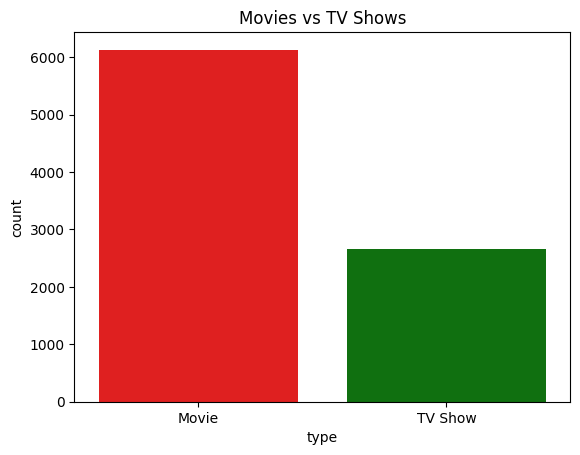

In [25]:
## Movies vs TV Shows
sns.countplot(x='type', data=df, palette=['red', 'green'])
plt.title("Movies vs TV Shows")
plt.show()

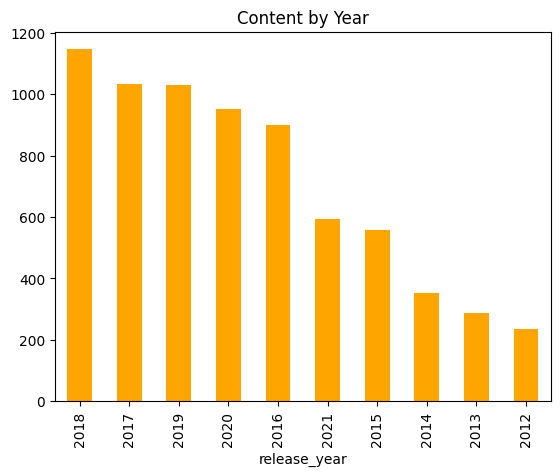

In [26]:
## Content by Year
df['release_year'].value_counts().head(10).plot(kind='bar',color='orange')
plt.title('Content by Year')
plt.show()

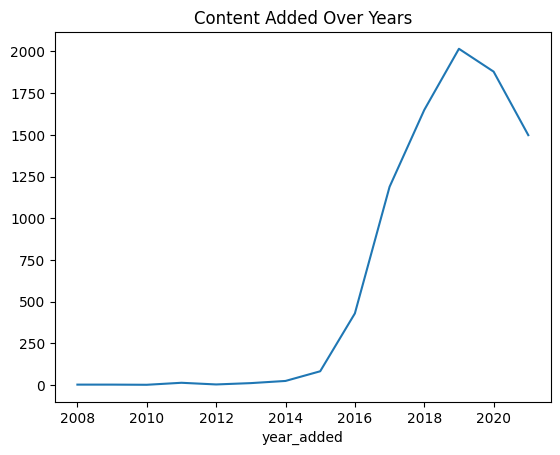

In [27]:
## Content Growth Over Time
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Years")
plt.show()

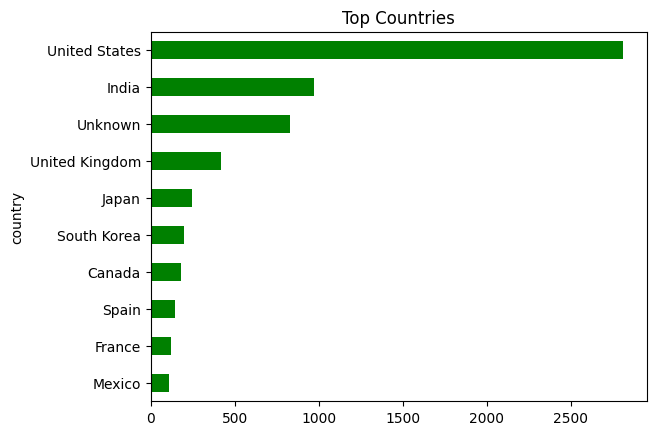

In [28]:
## Top Countries
df['country'].value_counts().head(10).sort_values().plot(kind='barh',color='green')
plt.title("Top Countries")
plt.show()

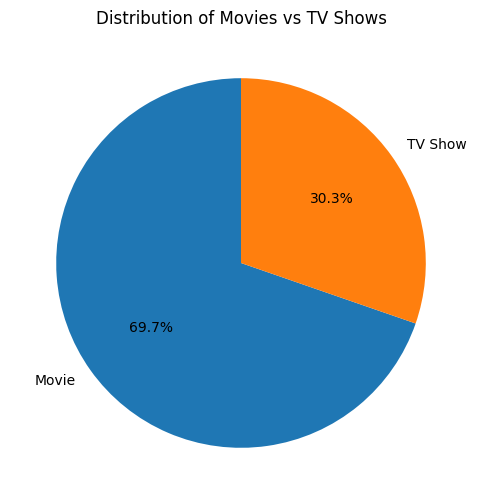

In [29]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts, 
        labels=type_counts.index, 
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Movies vs TV Shows")
plt.show()

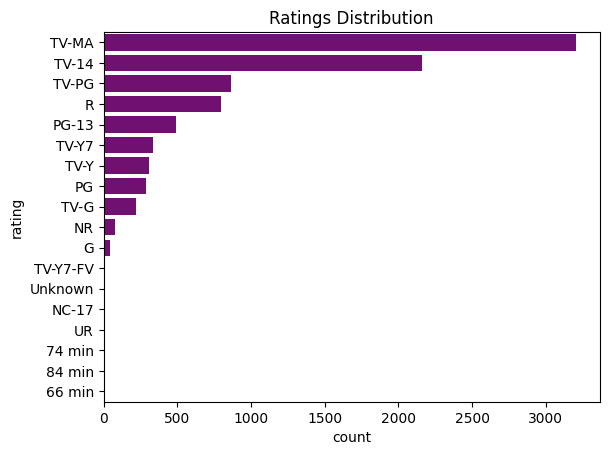

In [30]:
## Ratings Distribution
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index,color='purple')
plt.title("Ratings Distribution")
plt.show()

In [31]:
movies = df[df['type'] == 'Movie'].copy()

In [32]:
movies = movies[movies['duration'].str.contains('min', na=False)]

In [33]:
movies['duration'] = movies['duration'].str.replace(' min','')
movies['duration'] = movies['duration'].astype(float)

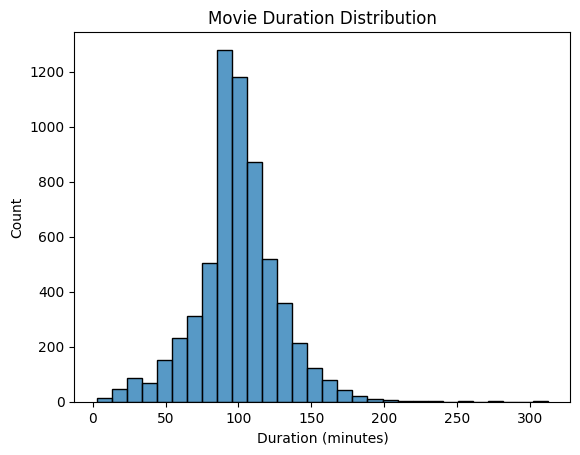

In [34]:
sns.histplot(movies['duration'], bins=30)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.show()

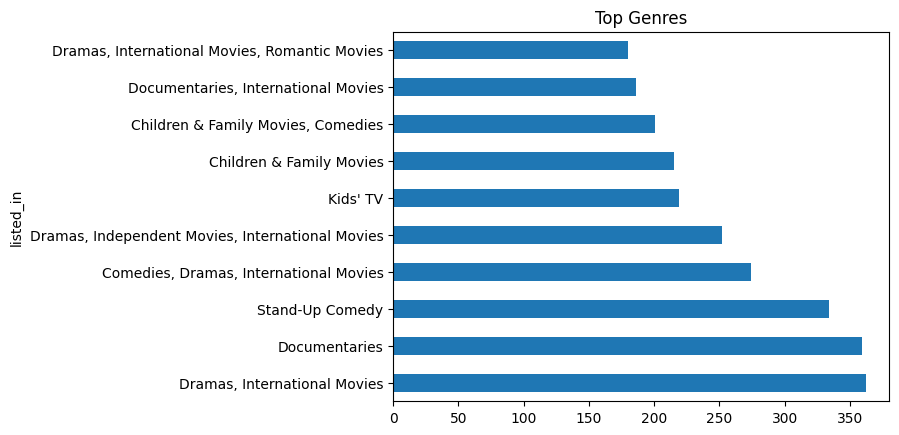

In [35]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()

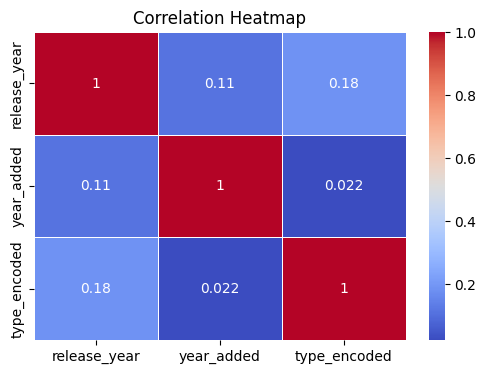

In [36]:
df['type_encoded'] = df['type'].map({'Movie':0, 'TV Show':1})
num_df = df[['release_year', 'year_added', 'type_encoded']]
corr = num_df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()